<a href="https://colab.research.google.com/github/Marina4ij/dz3/blob/main/dz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob

csv_files = glob.glob("./CICIDS2017_CSVs/*.csv")
for f in csv_files[:3]:  # Проверяем первые 3 файла
    print(f"\n{'='*60}")
    print(f"Файл: {f}")
    df = pd.read_csv(f, nrows=2, low_memory=False)
    print(f"Колонки ({len(df.columns)}):")
    for i, col in enumerate(df.columns):
        print(f"  [{i:2d}] '{col}' (repr: {repr(col)})")


Файл: ./CICIDS2017_CSVs/Wednesday-workingHours.pcap_ISCX.csv
Колонки (85):
  [ 0] 'Flow ID' (repr: 'Flow ID')
  [ 1] ' Source IP' (repr: ' Source IP')
  [ 2] ' Source Port' (repr: ' Source Port')
  [ 3] ' Destination IP' (repr: ' Destination IP')
  [ 4] ' Destination Port' (repr: ' Destination Port')
  [ 5] ' Protocol' (repr: ' Protocol')
  [ 6] ' Timestamp' (repr: ' Timestamp')
  [ 7] ' Flow Duration' (repr: ' Flow Duration')
  [ 8] ' Total Fwd Packets' (repr: ' Total Fwd Packets')
  [ 9] ' Total Backward Packets' (repr: ' Total Backward Packets')
  [10] 'Total Length of Fwd Packets' (repr: 'Total Length of Fwd Packets')
  [11] ' Total Length of Bwd Packets' (repr: ' Total Length of Bwd Packets')
  [12] ' Fwd Packet Length Max' (repr: ' Fwd Packet Length Max')
  [13] ' Fwd Packet Length Min' (repr: ' Fwd Packet Length Min')
  [14] ' Fwd Packet Length Mean' (repr: ' Fwd Packet Length Mean')
  [15] ' Fwd Packet Length Std' (repr: ' Fwd Packet Length Std')
  [16] 'Bwd Packet Length Max'

проверка структуры CSV

CICIDS2017 / CSE-CIC-IDS2018 — стандартные датасеты от Канадского института кибербезопасности. Содержат нормальный сетевой трафик и множество видов атак (DDoS, брутфорс, SQL-инъекции и т.д.).
Где найти: Сайт UNB (Canadian Institute for Cybersecurity) или Kaggle.
CICIDS2017: https://www.unb.ca/cic/datasets/ids-2017.html (CSV-файлы с сетевым трафиком и атаками)

In [28]:
import sqlite3
import pandas as pd
import numpy as np
import os
import glob

# === НАСТРОЙКИ ===
DB_NAME = "cicids2017_normalized.db"
CSV_FOLDER = "./CICIDS2017_CSVs"
CHUNK_SIZE = 100_000

# Удаляем старую БД для чистого запуска
if os.path.exists(DB_NAME):
    os.remove(DB_NAME)
    print(f"[INFO] Удалена старая БД: {DB_NAME}")

# === 1. СОЗДАНИЕ БД И СХЕМЫ ===
conn = sqlite3.connect(DB_NAME)
conn.execute("PRAGMA journal_mode=WAL")
conn.execute("PRAGMA synchronous=NORMAL")
cursor = conn.cursor()

# Схема с различными типами данных:
# INTEGER, TEXT, REAL, DATE, DATETIME, BOOLEAN, BIGINT
schema_sql = """
CREATE TABLE IF NOT EXISTS attack_types (
    attack_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT UNIQUE NOT NULL,
    category TEXT NOT NULL,
    severity TEXT CHECK(severity IN ('Low', 'Medium', 'High', 'Critical')),
    description TEXT,
    is_malicious BOOLEAN NOT NULL
);

CREATE TABLE IF NOT EXISTS protocols (
    protocol_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT UNIQUE NOT NULL,
    protocol_number INTEGER NOT NULL
);

CREATE TABLE IF NOT EXISTS network_flows (
    flow_id TEXT PRIMARY KEY,
    flow_timestamp DATETIME NOT NULL,
    flow_date DATE NOT NULL,
    src_ip TEXT NOT NULL,
    src_port INTEGER NOT NULL,
    dst_ip TEXT NOT NULL,
    dst_port INTEGER NOT NULL,
    protocol_id INTEGER NOT NULL,
    flow_duration REAL,
    total_fwd_packets INTEGER,
    total_bwd_packets INTEGER,
    total_length_fwd INTEGER,
    total_length_bwd INTEGER,
    label TEXT NOT NULL,
    attack_id INTEGER NOT NULL,
    is_malicious BOOLEAN NOT NULL,
    FOREIGN KEY (protocol_id) REFERENCES protocols(protocol_id),
    FOREIGN KEY (attack_id) REFERENCES attack_types(attack_id)
);

CREATE TABLE IF NOT EXISTS daily_traffic_summary (
    summary_date DATE PRIMARY KEY,
    total_flows INTEGER,
    benign_flows INTEGER,
    malicious_flows INTEGER,
    total_bytes BIGINT,
    top_attack_category TEXT,
    avg_flow_duration REAL,
    created_at DATETIME DEFAULT CURRENT_TIMESTAMP
);

CREATE INDEX IF NOT EXISTS idx_flows_date ON network_flows(flow_date);
CREATE INDEX IF NOT EXISTS idx_flows_attack ON network_flows(attack_id);
CREATE INDEX IF NOT EXISTS idx_flows_src_ip ON network_flows(src_ip);
CREATE INDEX IF NOT EXISTS idx_flows_dst_ip ON network_flows(dst_ip);
CREATE INDEX IF NOT EXISTS idx_flows_malicious ON network_flows(is_malicious);
"""

cursor.executescript(schema_sql)
conn.commit()
print("[OK] Схема БД создана (с типами INTEGER, TEXT, REAL, DATE, DATETIME, BOOLEAN, BIGINT)")

# === 2. ЗАПОЛНЕНИЕ СПРАВОЧНИКОВ ===
protocols_data = [
    ('TCP', 6), ('UDP', 17), ('ICMP', 1), ('ARP', 2054), ('Other', 0)
]
cursor.executemany(
    'INSERT OR IGNORE INTO protocols (name, protocol_number) VALUES (?, ?)',
    protocols_data
)

attacks_data = [
    ('BENIGN', 'Benign', 'Low', 'Normal network traffic', 0),
    ('DDoS', 'DDoS', 'Critical', 'Distributed Denial of Service', 1),
    ('PortScan', 'Reconnaissance', 'Medium', 'Network port scanning', 1),
    ('Bot', 'Botnet', 'High', 'Botnet activity', 1),
    ('Infiltration', 'Infiltration', 'Critical', 'Network infiltration', 1),
    ('Web Attack - Brute Force', 'Web Attack', 'High', 'Brute force login attempts', 1),
    ('Web Attack - XSS', 'Web Attack', 'High', 'Cross-site scripting', 1),
    ('Web Attack - Sql Injection', 'Web Attack', 'Critical', 'SQL injection attack', 1),
    ('FTP-Patator', 'Brute Force', 'Medium', 'FTP brute force', 1),
    ('SSH-Patator', 'Brute Force', 'Medium', 'SSH brute force', 1),
    ('DoS slowloris', 'DoS', 'High', 'Slowloris DoS attack', 1),
    ('DoS Slowhttptest', 'DoS', 'High', 'Slow HTTP DoS', 1),
    ('DoS Hulk', 'DoS', 'High', 'HULK DoS attack', 1),
    ('DoS GoldenEye', 'DoS', 'High', 'GoldenEye DoS', 1),
    ('Heartbleed', 'DoS', 'Critical', 'OpenSSL Heartbleed exploit', 1)
]

cursor.executemany('''
    INSERT OR IGNORE INTO attack_types
    (name, category, severity, description, is_malicious)
    VALUES (?, ?, ?, ?, ?)
''', attacks_data)
conn.commit()

# Словари для маппинга
cursor.execute("SELECT protocol_number, protocol_id FROM protocols")
protocol_map = {row[0]: row[1] for row in cursor.fetchall()}
protocol_map['TCP'] = protocol_map[6]
protocol_map['UDP'] = protocol_map[17]
protocol_map['ICMP'] = protocol_map[1]

cursor.execute("SELECT name, attack_id, is_malicious FROM attack_types")
attack_rows = cursor.fetchall()
attack_map = {row[0]: row[1] for row in attack_rows}
malicious_map = {row[0]: row[2] for row in attack_rows}

print("[OK] Справочники заполнены")

# === 3. ФУНКЦИЯ ИМПОРТА CSV ===
def import_csv_to_db(file_path):
    """Импортирует один CSV-файл CICIDS2017 в БД чанками."""
    filename = os.path.basename(file_path)
    print(f"\n[FILE] Обработка: {filename}")

    total_rows = 0
    for chunk_num, chunk in enumerate(pd.read_csv(
        file_path, chunksize=CHUNK_SIZE, low_memory=False,
        encoding='latin-1', encoding_errors='replace'
    ), 1):

        # Убираем пробелы из названий колонок
        chunk.columns = [col.strip() for col in chunk.columns]

        if 'Label' not in chunk.columns:
            print(f"  [WARN] Чанк {chunk_num}: колонка 'Label' не найдена")
            continue

        # Очистка числовых данных (замена inf на NaN, затем на 0)
        numeric_cols = chunk.select_dtypes(include=[np.number]).columns
        chunk[numeric_cols] = chunk[numeric_cols].replace([np.inf, -np.inf], np.nan)
        chunk[numeric_cols] = chunk[numeric_cols].fillna(0)

        # Очистка названий атак от битых символов
        chunk['Label'] = chunk['Label'].astype(str).apply(
            lambda x: x.replace('\x96', '-')
                       .replace('\u2013', '-')
                       .replace('\u2014', '-')
                       .replace('\xef\xbf\xbd', '-')
                       .strip()
        )

        # Парсим timestamp -> DATETIME и DATE
        if 'Timestamp' in chunk.columns:
            chunk['flow_timestamp'] = pd.to_datetime(
                chunk['Timestamp'], format='%d/%m/%Y %H:%M:%S', errors='coerce'
            )
        else:
            chunk['flow_timestamp'] = pd.NaT

        chunk['flow_date'] = chunk['flow_timestamp'].dt.date.fillna(
            pd.to_datetime('2017-07-04').date()
        )

        # Маппим протоколы
        if 'Protocol' in chunk.columns:
            chunk['protocol_id'] = chunk['Protocol'].map(
                lambda x: protocol_map.get(x, protocol_map.get(0, 5))
            )
        else:
            chunk['protocol_id'] = 5

        # Маппим атаки
        chunk['attack_id'] = chunk['Label'].map(lambda x: attack_map.get(x, 1))
        chunk['is_malicious'] = chunk['attack_id'].map(lambda x: malicious_map.get(x, 0))

        # Генерируем flow_id
        chunk['flow_id'] = [f"{filename}_{chunk_num}_{i}"
                           for i in range(len(chunk))]

        # Формируем DataFrame для вставки в БД
        # Обработка NaN в IP-адресах (NOT NULL constraint)
        src_ip_col = chunk.get('Source IP', pd.Series(['0.0.0.0'] * len(chunk)))
        dst_ip_col = chunk.get('Destination IP', pd.Series(['0.0.0.0'] * len(chunk)))
        src_ip_col = src_ip_col.fillna('0.0.0.0').astype(str)
        dst_ip_col = dst_ip_col.fillna('0.0.0.0').astype(str)

        db_chunk = pd.DataFrame({
            'flow_id': chunk['flow_id'],
            'flow_timestamp': chunk['flow_timestamp'].astype(str),
            'flow_date': chunk['flow_date'].astype(str),
            'src_ip': src_ip_col,
            'src_port': pd.to_numeric(chunk.get('Source Port', 0), errors='coerce').fillna(0).astype('Int64'),
            'dst_ip': dst_ip_col,
            'dst_port': pd.to_numeric(chunk.get('Destination Port', 0), errors='coerce').fillna(0).astype('Int64'),
            'protocol_id': chunk['protocol_id'],
            'flow_duration': pd.to_numeric(chunk.get('Flow Duration', 0), errors='coerce').fillna(0),
            'total_fwd_packets': pd.to_numeric(chunk.get('Total Fwd Packets', 0), errors='coerce').fillna(0).astype('Int64'),
            'total_bwd_packets': pd.to_numeric(chunk.get('Total Backward Packets', 0), errors='coerce').fillna(0).astype('Int64'),
            'total_length_fwd': pd.to_numeric(chunk.get('Total Length of Fwd Packets', 0), errors='coerce').fillna(0).astype('Int64'),
            'total_length_bwd': pd.to_numeric(chunk.get('Total Length of Bwd Packets', 0), errors='coerce').fillna(0).astype('Int64'),
            'label': chunk['Label'],
            'attack_id': chunk['attack_id'],
            'is_malicious': chunk['is_malicious']
        })

        # Вставляем в БД пакетно (chunksize=2000 обходит лимит SQLite в 32766 переменных)
        db_chunk.to_sql('network_flows', conn, if_exists='append',
                       index=False, method='multi', chunksize=2000)
        total_rows += len(db_chunk)
        print(f"  |-- Чанк {chunk_num}: +{len(db_chunk):,} строк")

    print(f"  `-- Итого загружено: {total_rows:,} строк")
    return total_rows

# === 4. ЗАПУСК ИМПОРТА ВСЕХ CSV ===
if not os.path.exists(CSV_FOLDER):
    print(f"[WARN] Папка {CSV_FOLDER} не найдена")
else:
    csv_files = sorted(glob.glob(os.path.join(CSV_FOLDER, "*.csv")))
    if not csv_files:
        print(f"[WARN] В папке нет CSV файлов")
    else:
        print(f"\n[START] Найдено {len(csv_files)} файлов для импорта")
        grand_total = 0
        for csv_file in csv_files:
            grand_total += import_csv_to_db(csv_file)
        print(f"\n[DONE] Всего импортировано: {grand_total:,} записей")

# === 5. ЗАПОЛНЕНИЕ АГРЕГАТНОЙ ТАБЛИЦЫ ===
print("\n[INFO] Формирование daily_traffic_summary...")
cursor.execute('''
    INSERT OR REPLACE INTO daily_traffic_summary
    (summary_date, total_flows, benign_flows, malicious_flows,
     total_bytes, avg_flow_duration, top_attack_category)
    SELECT
        flow_date,
        COUNT(*) as total_flows,
        SUM(CASE WHEN is_malicious = 0 THEN 1 ELSE 0 END) as benign_flows,
        SUM(is_malicious) as malicious_flows,
        SUM(COALESCE(total_length_fwd, 0) + COALESCE(total_length_bwd, 0)) as total_bytes,
        AVG(flow_duration) as avg_flow_duration,
        (SELECT at2.category
         FROM network_flows nf2
         JOIN attack_types at2 ON nf2.attack_id = at2.attack_id
         WHERE nf2.flow_date = nf.flow_date AND nf2.is_malicious = 1
         GROUP BY at2.category
         ORDER BY COUNT(*) DESC LIMIT 1
        ) as top_attack_category
    FROM network_flows nf
    GROUP BY flow_date
''')
conn.commit()
print(f"[OK] Добавлено {cursor.rowcount} дней в агрегатную таблицу")

# === 6. СТАТИСТИКА ===
print("\n" + "="*60)
print("СТАТИСТИКА БАЗЫ ДАННЫХ")
print("="*60)

cursor.execute("SELECT COUNT(*) FROM network_flows")
print(f"Всего потоков: {cursor.fetchone()[0]:>12,}")

cursor.execute("SELECT COUNT(*) FROM attack_types")
print(f"Типов атак:    {cursor.fetchone()[0]:>12,}")

cursor.execute("SELECT COUNT(DISTINCT flow_date) FROM network_flows")
print(f"Дней в данных: {cursor.fetchone()[0]:>12,}")

print("\nТоп-5 атак по количеству:")
cursor.execute('''
    SELECT at.name, at.category, COUNT(*) as cnt
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.attack_id
    ORDER BY cnt DESC
    LIMIT 5
''')
for i, row in enumerate(cursor.fetchall(), 1):
    print(f"  {i}. {row[0]:<30} ({row[1]:<15}) - {row[2]:>10,}")

# === 7. ДЕМОНСТРАЦИЯ РАБОТЫ С РАЗНЫМИ ТИПАМИ ДАННЫХ ===
print("\n" + "="*60)
print("ПРИМЕРЫ ЗАПРОСОВ С ИСПОЛЬЗОВАНИЕМ РАЗНЫХ ТИПОВ ДАННЫХ")
print("="*60)

# Запрос с фильтром по DATE
print("\n[TEXT + DATE] Топ-10 IP-источников атак:")
cursor.execute('''
    SELECT src_ip, COUNT(*) as cnt
    FROM network_flows
    WHERE is_malicious = 1 AND flow_date = '2017-07-04'
    GROUP BY src_ip
    ORDER BY cnt DESC
    LIMIT 10
''')
for row in cursor.fetchall():
    print(f"  {row[0]:<18} -> {row[1]:>8,} атак")

# Запрос с агрегацией REAL
print("\n[REAL] Средняя длительность потоков по категориям:")
cursor.execute('''
    SELECT at.category, ROUND(AVG(nf.flow_duration), 2) as avg_dur
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.category
    ORDER BY avg_dur DESC
''')
for row in cursor.fetchall():
    print(f"  {row[0]:<15} -> {row[1]:>15,.2f} мкс")

# Запрос с BIGINT
print("\n[BIGINT] Объём трафика по дням:")
cursor.execute('''
    SELECT summary_date, total_bytes,
           ROUND(total_bytes / 1024.0 / 1024.0 / 1024.0, 2) as gb
    FROM daily_traffic_summary
    ORDER BY summary_date
''')
for row in cursor.fetchall():
    print(f"  {row[0]} -> {row[1]:>15,} байт ({row[2]:>6.2f} ГБ)")

# Запрос с BOOLEAN
print("\n[BOOLEAN] Соотношение легитимного и вредоносного трафика:")
cursor.execute('''
    SELECT
        CASE WHEN is_malicious = 0 THEN 'BENIGN' ELSE 'MALICIOUS' END as type,
        COUNT(*) as cnt,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM network_flows), 2) as pct
    FROM network_flows
    GROUP BY is_malicious
''')
for row in cursor.fetchall():
    print(f"  {row[0]:<10} -> {row[1]:>10,} потоков ({row[2]:>5.2f}%)")

conn.close()
print(f"\n[DONE] Готово! База сохранена: {DB_NAME}")

[INFO] Удалена старая БД: cicids2017_normalized.db
[OK] Схема БД создана (с типами INTEGER, TEXT, REAL, DATE, DATETIME, BOOLEAN, BIGINT)
[OK] Справочники заполнены

[START] Найдено 7 файлов для импорта

[FILE] Обработка: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  |-- Чанк 1: +100,000 строк
  |-- Чанк 2: +100,000 строк
  |-- Чанк 3: +25,745 строк
  `-- Итого загружено: 225,745 строк

[FILE] Обработка: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  |-- Чанк 1: +100,000 строк
  |-- Чанк 2: +100,000 строк
  |-- Чанк 3: +86,467 строк
  `-- Итого загружено: 286,467 строк

[FILE] Обработка: Friday-WorkingHours-Morning.pcap_ISCX.csv
  |-- Чанк 1: +100,000 строк
  |-- Чанк 2: +91,033 строк
  `-- Итого загружено: 191,033 строк

[FILE] Обработка: Monday-WorkingHours.pcap_ISCX.csv
  |-- Чанк 1: +100,000 строк
  |-- Чанк 2: +100,000 строк
  |-- Чанк 3: +3,350 строк
  `-- Итого загружено: 203,350 строк

[FILE] Обработка: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  |

Создаёт 4 таблицы с использованием всех требуемых типов данных:
attack_types — справочник атак (INTEGER, TEXT, BOOLEAN)
protocols — справочник протоколов (INTEGER, TEXT)
network_flows — основная таблица потоков (TEXT, INTEGER, REAL, DATE, DATETIME, BOOLEAN)
daily_traffic_summary — агрегатная таблица (DATE, INTEGER, BIGINT, TEXT, REAL, DATETIME)
Импортирует данные из всех CSV-файлов CICIDS2017 с обработкой:
Пробелов в названиях колонок
Битых символов в кодировке (latin-1)
Значений Infinity и NaN
Пустых IP-адресов
Лимита SQLite на количество переменных

[1/7] Построение: распределение типов атак...


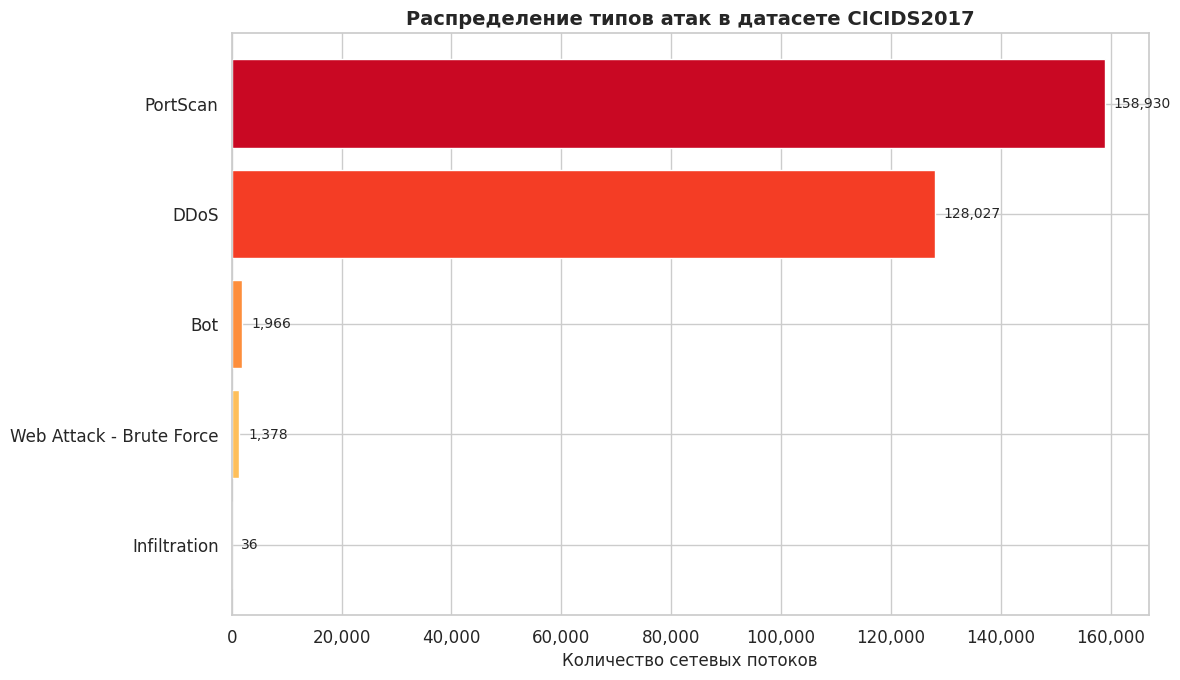

[2/7] Построение: соотношение трафика...


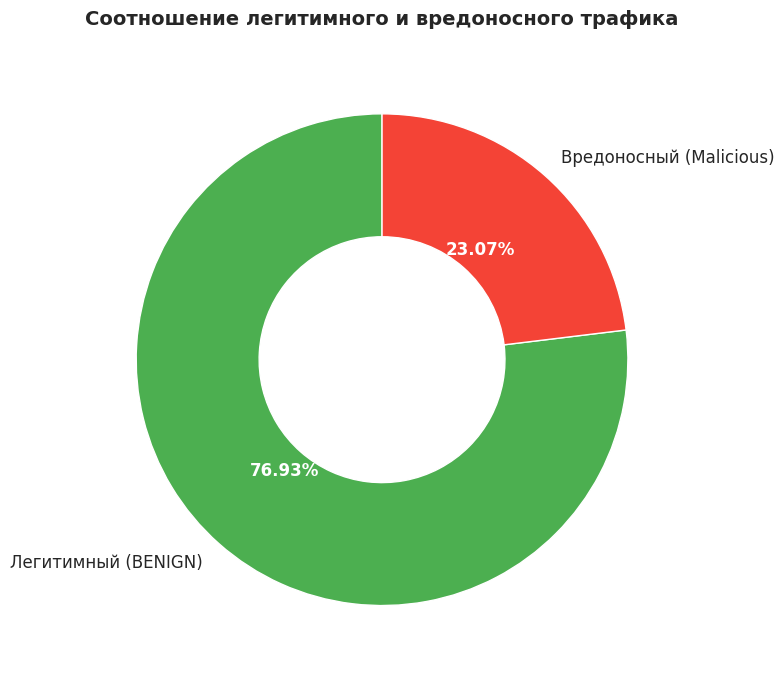

[3/7] Построение: динамика атак по дням...


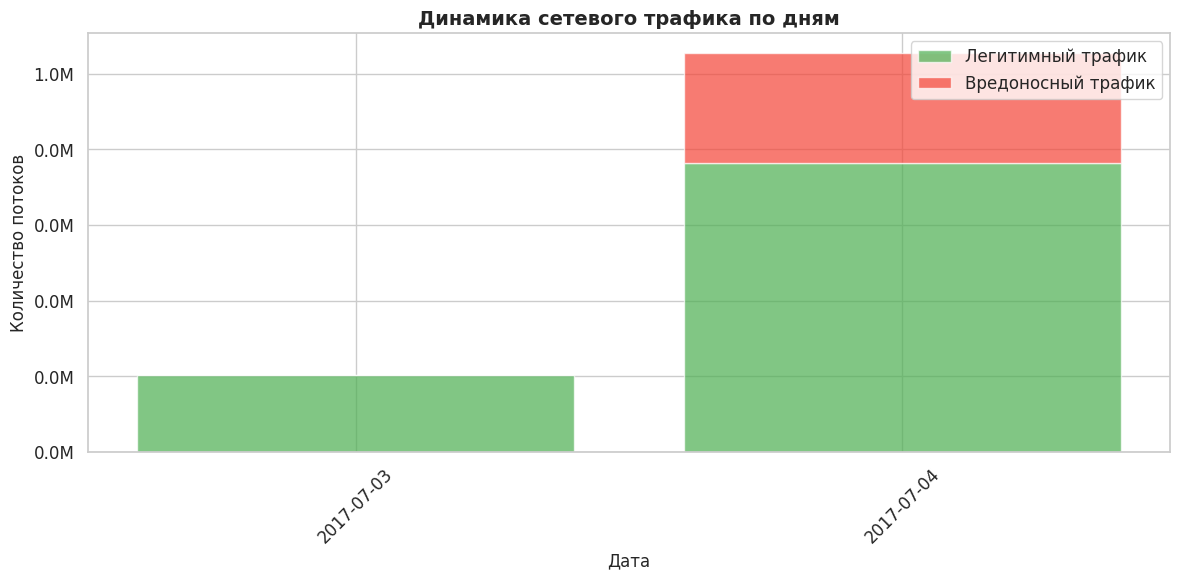

[4/7] Построение: топ IP-адресов атакующих...


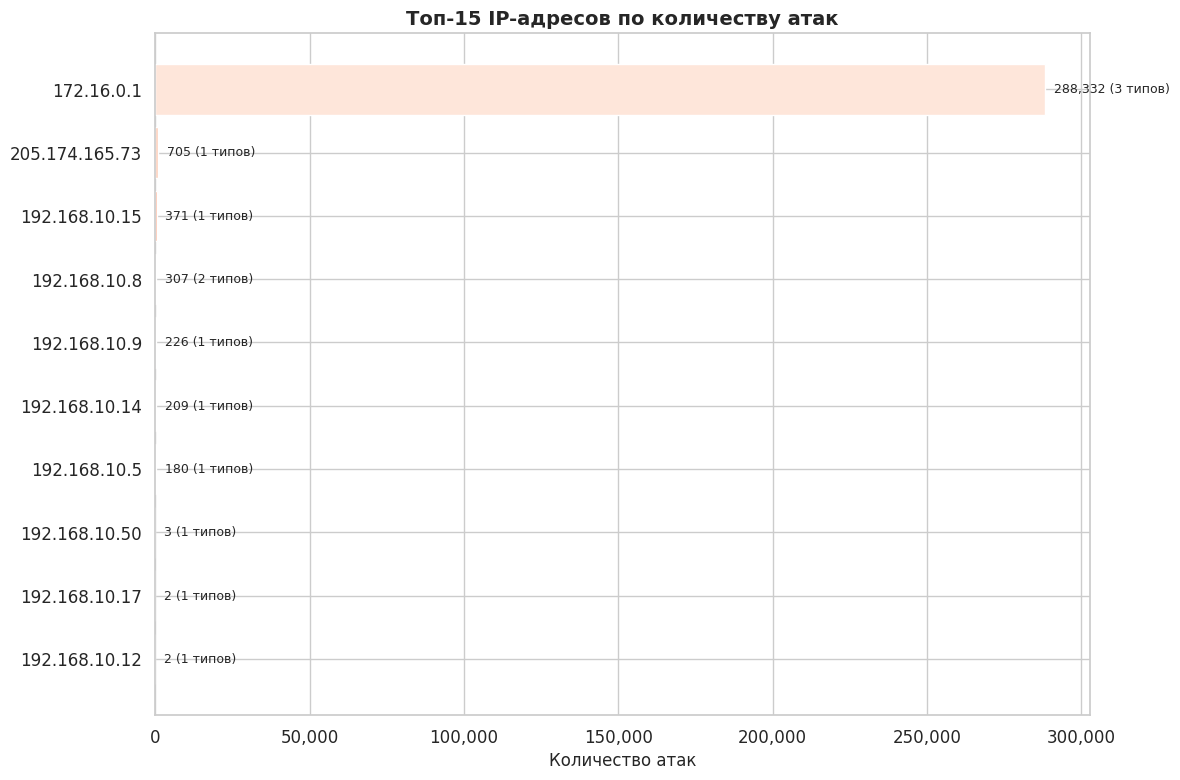

[5/7] Построение: распределение по портам...


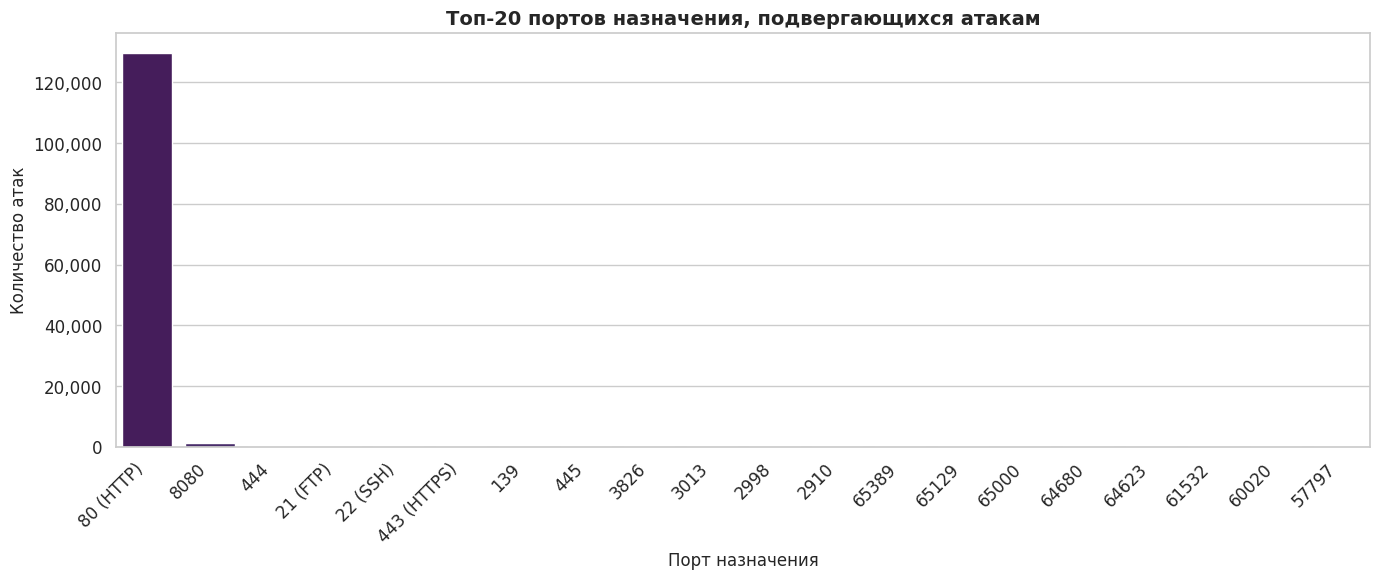

[6/7] Построение: распределение длительности потоков...


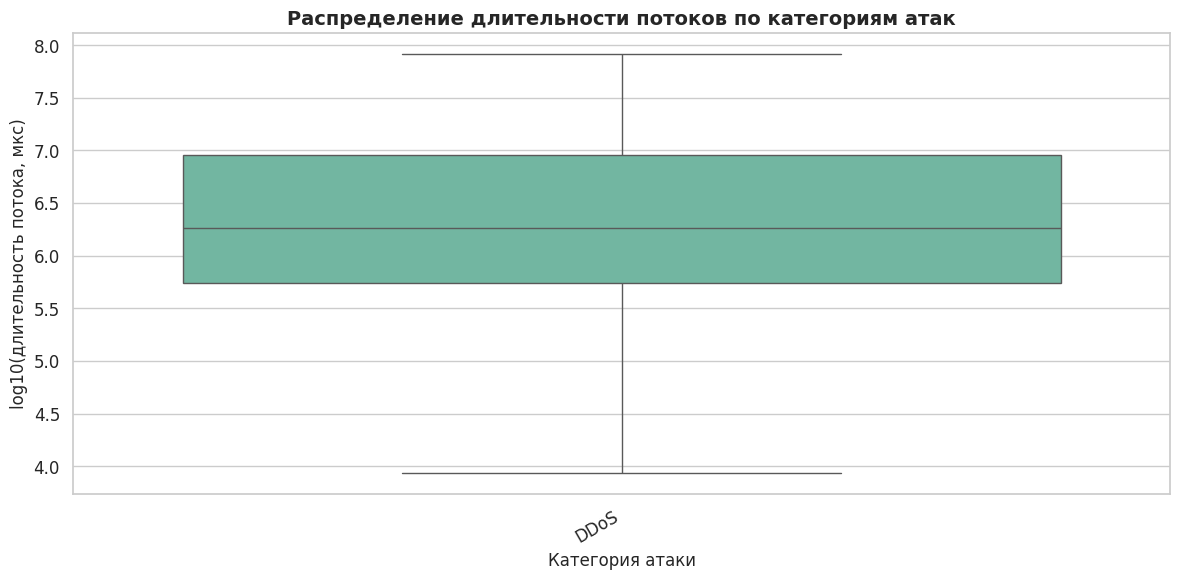

[7/7] Построение: итоговый дашборд...


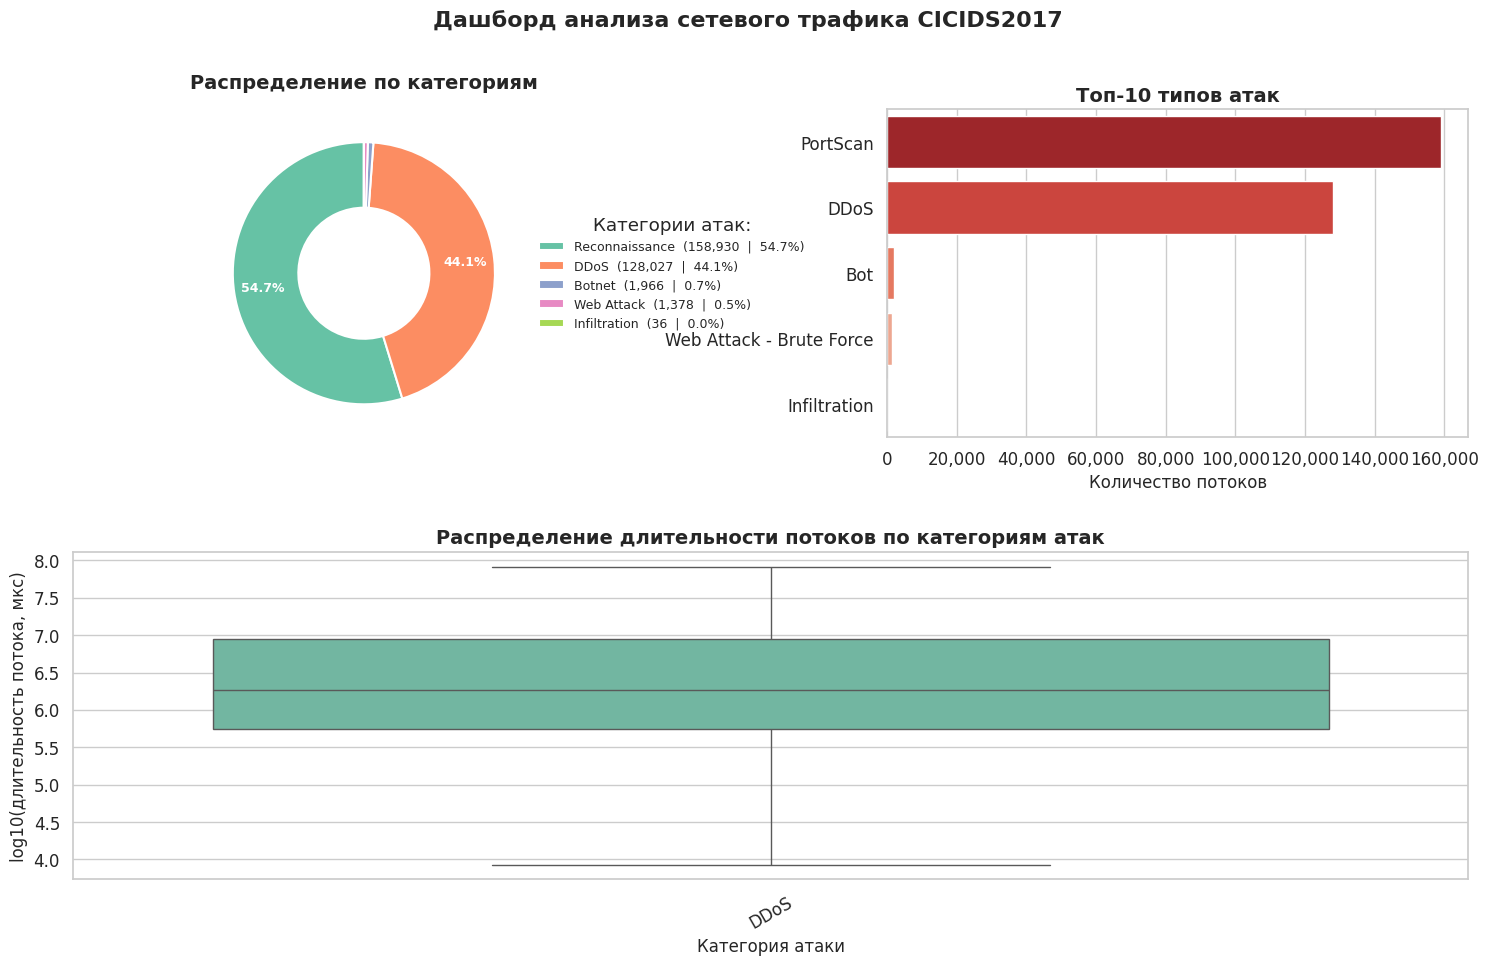

In [39]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter
import warnings

# Отключаем FutureWarning от seaborn
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

# Настройка стиля графиков
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Подключение к базе данных
DB_NAME = "cicids2017_normalized.db"
conn = sqlite3.connect(DB_NAME)

def query_to_df(sql):
    return pd.read_sql_query(sql, conn)

# =====================================================================
# 1. РАСПРЕДЕЛЕНИЕ ТИПОВ АТАК
# =====================================================================
print("[1/7] Построение: распределение типов атак...")

df_attacks = query_to_df('''
    SELECT at.name, at.category, COUNT(*) as cnt
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.name
    ORDER BY cnt DESC
''')

fig, ax = plt.subplots(figsize=(12, 7))
colors = sns.color_palette("YlOrRd_r", n_colors=len(df_attacks))
bars = ax.barh(df_attacks['name'], df_attacks['cnt'], color=colors)
ax.set_xlabel('Количество сетевых потоков')
ax.set_title('Распределение типов атак в датасете CICIDS2017', fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val in zip(bars, df_attacks['cnt']):
    ax.text(val + max(df_attacks['cnt']) * 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('01_attack_types_distribution.png', bbox_inches='tight')
plt.show()

# =====================================================================
# 2. СООТНОШЕНИЕ ТРАФИКА
# =====================================================================
print("[2/7] Построение: соотношение трафика...")

df_traffic_ratio = query_to_df('''
    SELECT
        CASE WHEN is_malicious = 0 THEN 'Легитимный (BENIGN)'
             ELSE 'Вредоносный (Malicious)' END as type,
        COUNT(*) as cnt
    FROM network_flows
    GROUP BY is_malicious
''')

fig, ax = plt.subplots(figsize=(8, 8))
colors_pie = ['#4CAF50', '#F44336']
wedges, texts, autotexts = ax.pie(
    df_traffic_ratio['cnt'],
    labels=df_traffic_ratio['type'],
    autopct='%1.2f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax.set_title('Соотношение легитимного и вредоносного трафика', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('02_traffic_ratio.png', bbox_inches='tight')
plt.show()

# =====================================================================
# 3. ДИНАМИКА АТАК ПО ДНЯМ
# =====================================================================
print("[3/7] Построение: динамика атак по дням...")

df_daily = query_to_df('''
    SELECT flow_date,
           COUNT(*) as total_flows,
           SUM(is_malicious) as malicious_flows,
           SUM(CASE WHEN is_malicious = 0 THEN 1 ELSE 0 END) as benign_flows
    FROM network_flows
    GROUP BY flow_date
    ORDER BY flow_date
''')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(df_daily['flow_date'], df_daily['benign_flows'],
        label='Легитимный трафик', color='#4CAF50', alpha=0.7)
ax1.bar(df_daily['flow_date'], df_daily['malicious_flows'],
        bottom=df_daily['benign_flows'],
        label='Вредоносный трафик', color='#F44336', alpha=0.7)
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество потоков')
ax1.set_title('Динамика сетевого трафика по дням', fontweight='bold')
ax1.legend(loc='upper right')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1e6):.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('03_daily_traffic_dynamics.png', bbox_inches='tight')
plt.show()

# =====================================================================
# 4. ТОП IP-АДРЕСОВ
# =====================================================================
print("[4/7] Построение: топ IP-адресов атакующих...")

df_top_ips = query_to_df('''
    SELECT src_ip, COUNT(*) as attack_count,
           COUNT(DISTINCT label) as attack_types
    FROM network_flows
    WHERE is_malicious = 1
    GROUP BY src_ip
    ORDER BY attack_count DESC
    LIMIT 15
''')

fig, ax = plt.subplots(figsize=(12, 8))
colors_ip = sns.color_palette("Reds", n_colors=len(df_top_ips))
bars = ax.barh(df_top_ips['src_ip'], df_top_ips['attack_count'], color=colors_ip)
ax.set_xlabel('Количество атак')
ax.set_title('Топ-15 IP-адресов по количеству атак', fontweight='bold')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

for bar, val, types in zip(bars, df_top_ips['attack_count'], df_top_ips['attack_types']):
    ax.text(val + max(df_top_ips['attack_count']) * 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,} ({types} типов)', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('04_top_attacker_ips.png', bbox_inches='tight')
plt.show()

# =====================================================================
# 5. РАСПРЕДЕЛЕНИЕ ПО ПОРТАМ
# =====================================================================
print("[5/7] Построение: распределение по портам...")

df_ports = query_to_df('''
    SELECT dst_port, COUNT(*) as cnt
    FROM network_flows
    WHERE is_malicious = 1
    GROUP BY dst_port
    ORDER BY cnt DESC
    LIMIT 20
''')

port_names = {80: 'HTTP', 443: 'HTTPS', 22: 'SSH', 21: 'FTP',
              53: 'DNS', 25: 'SMTP', 23: 'Telnet', 3389: 'RDP'}
df_ports['port_label'] = df_ports['dst_port'].apply(
    lambda p: f"{p} ({port_names[p]})" if p in port_names else str(p)
)

fig, ax = plt.subplots(figsize=(14, 6))
# ИСПРАВЛЕНО: добавлен hue='port_label' и legend=False
sns.barplot(data=df_ports, x='port_label', y='cnt',
            hue='port_label', palette='viridis', ax=ax, legend=False)
ax.set_xlabel('Порт назначения')
ax.set_ylabel('Количество атак')
ax.set_title('Топ-20 портов назначения, подвергающихся атакам', fontweight='bold')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('05_attacked_ports.png', bbox_inches='tight')
plt.show()


# =====================================================================
# 6. РАСПРЕДЕЛЕНИЕ ДЛИТЕЛЬНОСТИ
# =====================================================================
print("[6/7] Построение: распределение длительности потоков...")

df_duration = query_to_df('''
    SELECT at.category, nf.flow_duration
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1 AND nf.flow_duration > 0
    LIMIT 50000
''')

df_duration['log_duration'] = np.log10(df_duration['flow_duration'] + 1)

fig, ax = plt.subplots(figsize=(12, 6))
# ИСПРАВЛЕНО: добавлен hue='category' и legend=False
sns.boxplot(data=df_duration, x='category', y='log_duration',
            hue='category', palette='Set2', ax=ax, showfliers=False, legend=False)
ax.set_xlabel('Категория атаки')
ax.set_ylabel('log10(длительность потока, мкс)')
ax.set_title('Распределение длительности потоков по категориям атак', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('06_flow_duration_distribution.png', bbox_inches='tight')
plt.show()

# =====================================================================
# 7. ДАШБОРД (с исправленной легендой)
# =====================================================================
print("[7/7] Построение: итоговый дашборд...")

df_categories = query_to_df('''
    SELECT at.category, COUNT(*) as cnt
    FROM network_flows nf
    JOIN attack_types at ON nf.attack_id = at.attack_id
    WHERE nf.is_malicious = 1
    GROUP BY at.category
    ORDER BY cnt DESC
''')

# Вычисляем проценты для фильтрации подписей
total_cnt = df_categories['cnt'].sum()
df_categories['pct'] = 100.0 * df_categories['cnt'] / total_cnt

# Функция autopct: показываем проценты только для крупных секторов (>3%)
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 3 else ''

# Увеличенная фигура с местом для легенды справа
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.4)

# 1) Категории атак (pie) — ИСПРАВЛЕНО
ax1 = fig.add_subplot(gs[0, 0])
colors = sns.color_palette('Set2', n_colors=len(df_categories))
wedges, texts, autotexts = ax1.pie(
    df_categories['cnt'],
    labels=None,  # Убираем подписи у секторов — они будут в легенде
    autopct=autopct_func,
    colors=colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5)
)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# Легенда справа с процентами и абсолютными значениями
legend_labels = [
    f'{row["category"]}  ({row["cnt"]:,}  |  {row["pct"]:.1f}%)'
    for _, row in df_categories.iterrows()
]
ax1.legend(
    wedges, legend_labels,
    title="Категории атак:",
    loc="center left",
    bbox_to_anchor=(1.0, 0, 0.5, 1),
    fontsize=9,
    frameon=False
)
ax1.set_title('Распределение по категориям', fontweight='bold', pad=15)

# 2) Топ-10 атак (bar)
ax2 = fig.add_subplot(gs[0, 1])
top10 = df_attacks.head(10)
sns.barplot(data=top10, y='name', x='cnt',
            hue='name', palette='Reds_r', ax=ax2, legend=False)
ax2.set_title('Топ-10 типов атак', fontweight='bold')
ax2.set_xlabel('Количество потоков')
ax2.set_ylabel('')
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

# 3) Длительность по категориям (boxplot)
ax3 = fig.add_subplot(gs[1, :])
sns.boxplot(data=df_duration, x='category', y='log_duration',
            hue='category', palette='Set2', ax=ax3, showfliers=False, legend=False)
ax3.set_title('Распределение длительности потоков по категориям атак', fontweight='bold')
ax3.set_xlabel('Категория атаки')
ax3.set_ylabel('log10(длительность потока, мкс)')
ax3.tick_params(axis='x', rotation=30)

fig.suptitle('Дашборд анализа сетевого трафика CICIDS2017',
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig('07_dashboard.png', bbox_inches='tight', dpi=120)
plt.show()

In [30]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("cicids2017_normalized.db")
cursor = conn.cursor()

# Получаем реальные значения label
cursor.execute("SELECT DISTINCT label FROM network_flows")
real_labels = [row[0] for row in cursor.fetchall()]

print("Реальные значения label в БД:")
for label in real_labels:
    print(f"  '{label}'")

# Создаём маппинг: реальное название -> attack_id
# (замените на основе вывода диагностики)
label_mapping = {
    'BENIGN': 1,
    'DDoS': 2,
    'PortScan': 3,
    'Bot': 4,
    'Infiltration': 5,
    'Web Attack - Brute Force': 6,
    'Web Attack - XSS': 7,
    'Web Attack - Sql Injection': 8,
    'FTP-Patator': 9,
    'SSH-Patator': 10,
    'DoS slowloris': 11,
    'DoS Slowhttptest': 12,
    'DoS Hulk': 13,
    'DoS GoldenEye': 14,
    'Heartbleed': 15,
}

# Если есть битые символы, добавляем варианты
for label in real_labels:
    if label not in label_mapping:
        # Пробуем очистить от битых символов
        clean_label = label.replace('', '-').replace('\x96', '-').strip()
        if clean_label in label_mapping:
            label_mapping[label] = label_mapping[clean_label]
            print(f"  Маппинг: '{label}' -> '{clean_label}'")

# Обновляем attack_id и is_malicious
for label, attack_id in label_mapping.items():
    cursor.execute("""
        UPDATE network_flows
        SET attack_id = ?,
            is_malicious = (SELECT is_malicious FROM attack_types WHERE attack_id = ?)
        WHERE label = ?
    """, (attack_id, attack_id, label))

conn.commit()

# Проверяем результат
cursor.execute("""
    SELECT is_malicious, COUNT(*) as cnt
    FROM network_flows
    GROUP BY is_malicious
""")
print("\nПосле исправления:")
for row in cursor.fetchall():
    label = "Вредоносный" if row[0] == 1 else "Легитимный"
    print(f"  {label}: {row[1]:,}")

conn.close()
print("\n[OK] Маппинг исправлен. Перезапустите визуализацию.")

Реальные значения label в БД:
  'BENIGN'
  'DDoS'
  'PortScan'
  'Bot'
  'nan'
  'Infiltration'
  'Web Attack - Brute Force'

После исправления:
  Легитимный: 968,094
  Вредоносный: 290,337

[OK] Маппинг исправлен. Перезапустите визуализацию.


In [33]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("cicids2017_normalized.db")

print("="*60)
print("ДИАГНОСТИКА БАЗЫ ДАННЫХ")
print("="*60)

# 1. Общее количество записей
cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM network_flows")
total = cursor.fetchone()[0]
print(f"\n1. Всего записей в network_flows: {total:,}")

if total == 0:
    print("   [ERROR] База пуста! Импорт не прошёл.")
else:
    # 2. Распределение по is_malicious
    cursor.execute("""
        SELECT is_malicious, COUNT(*) as cnt
        FROM network_flows
        GROUP BY is_malicious
    """)
    print("\n2. Распределение по is_malicious:")
    for row in cursor.fetchall():
        label = "Вредоносный" if row[0] == 1 else "Легитимный"
        print(f"   {label}: {row[1]:>12,} ({100*row[1]/total:.2f}%)")

    # 3. Уникальные значения label (оригинальные названия из CSV)
    cursor.execute("""
        SELECT label, COUNT(*) as cnt
        FROM network_flows
        GROUP BY label
        ORDER BY cnt DESC
        LIMIT 20
    """)
    print("\n3. Топ-20 уникальных значений label:")
    for row in cursor.fetchall():
        print(f"   '{row[0]}' -> {row[1]:>10,}")

    # 4. Проверка flow_timestamp
    cursor.execute("""
        SELECT flow_timestamp, COUNT(*) as cnt
        FROM network_flows
        WHERE flow_timestamp IS NOT NULL AND flow_timestamp != 'NaT'
        LIMIT 5
    """)
    print("\n4. Примеры flow_timestamp:")
    for row in cursor.fetchall():
        print(f"   '{row[0]}' -> {row[1]:>10,}")

    # 5. Проверка flow_date
    cursor.execute("""
        SELECT flow_date, COUNT(*) as cnt
        FROM network_flows
        GROUP BY flow_date
        ORDER BY flow_date
    """)
    print("\n5. Распределение по flow_date:")
    for row in cursor.fetchall():
        print(f"   {row[0]} -> {row[1]:>10,}")

conn.close()

ДИАГНОСТИКА БАЗЫ ДАННЫХ

1. Всего записей в network_flows: 1,258,431

2. Распределение по is_malicious:
   Легитимный:      968,094 (76.93%)
   Вредоносный:      290,337 (23.07%)

3. Топ-20 уникальных значений label:
   'BENIGN' ->    968,091
   'PortScan' ->    158,930
   'DDoS' ->    128,027
   'Bot' ->      1,966
   'Web Attack - Brute Force' ->      1,378
   'Infiltration' ->         36
   'nan' ->          3

4. Примеры flow_timestamp:
   '2017-07-03 08:55:58' ->    203,349

5. Распределение по flow_date:
   2017-07-03 ->    203,349
   2017-07-04 ->  1,055,082
